# Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Loading the dataset and some info about it

In [3]:
df= pd.read_csv("/Users/ragiatarek/pump_it_up_competition/docs/train.csv")

In [4]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  str    
 3   funder                 55763 non-null  str    
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  str    
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  str    
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  str    
 11  subvillage             59029 non-null  str    
 12  region                 59400 non-null  str    
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lga          

In [6]:
df.columns.to_list()

['id',
 'amount_tsh',
 'date_recorded',
 'funder',
 'gps_height',
 'installer',
 'longitude',
 'latitude',
 'wpt_name',
 'num_private',
 'basin',
 'subvillage',
 'region',
 'region_code',
 'district_code',
 'lga',
 'ward',
 'population',
 'public_meeting',
 'recorded_by',
 'scheme_management',
 'scheme_name',
 'permit',
 'construction_year',
 'extraction_type',
 'extraction_type_group',
 'extraction_type_class',
 'management',
 'management_group',
 'payment',
 'payment_type',
 'water_quality',
 'quality_group',
 'quantity',
 'quantity_group',
 'source',
 'source_type',
 'source_class',
 'waterpoint_type',
 'waterpoint_type_group',
 'status_group']

## Missing values

In [20]:
missing_values = df.isnull().sum()
missing_values


id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_

 ### `Conclusion`

#### we should consider removing scheme_name as almost half of it is missing

# EDA for numerical features

## 1. skewness and KDE

In [7]:
numerical_cols = df.select_dtypes(include="number")
numerical_cols.skew()

id                    0.002623
amount_tsh           57.807800
gps_height            0.462402
longitude            -4.191046
latitude             -0.152037
num_private          91.933750
region_code           3.173818
district_code         3.962045
population           12.660714
construction_year    -0.634928
dtype: float64

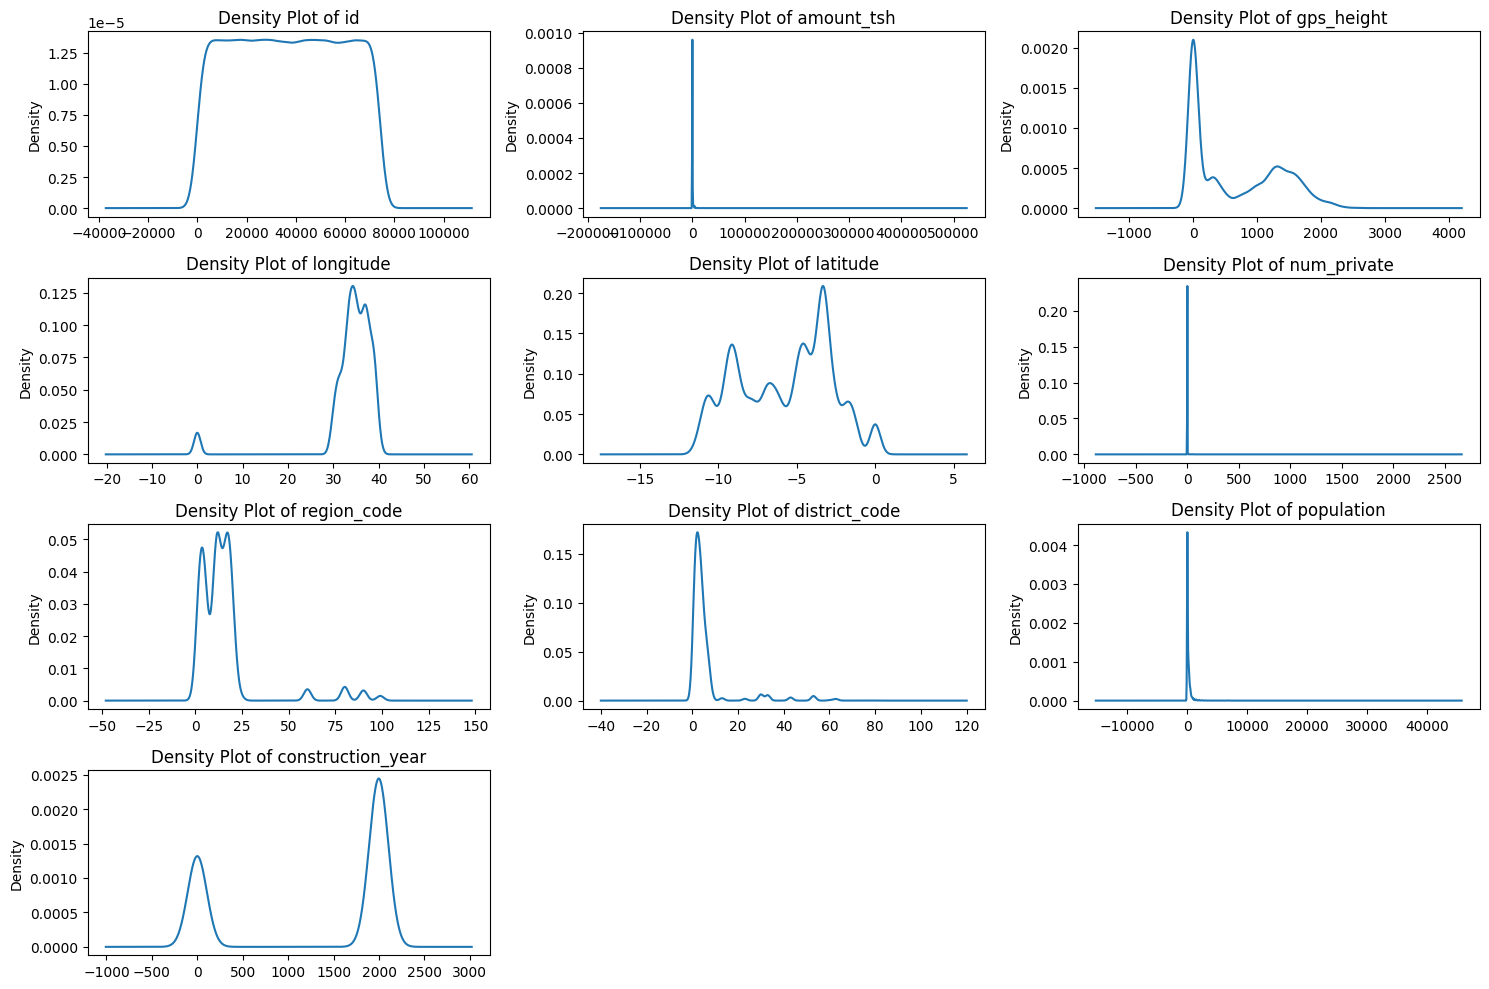

In [11]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols.columns.tolist()):
    plt.subplot(4, 3, i+1)
    numerical_cols[col].plot(kind='kde')
    plt.title(f'Density Plot of {col}')
plt.tight_layout()
plt.show()

 ### `Conclusion`

#### "num_private", "amount_tsh", and "population" are highly skewed (skewness > 1), aka have asymmetric distributions with long right tails. This may be due to outliers or the natural distribution of the data and we will confirm with box plots / IQR analysis later on

## 2. Boxplots

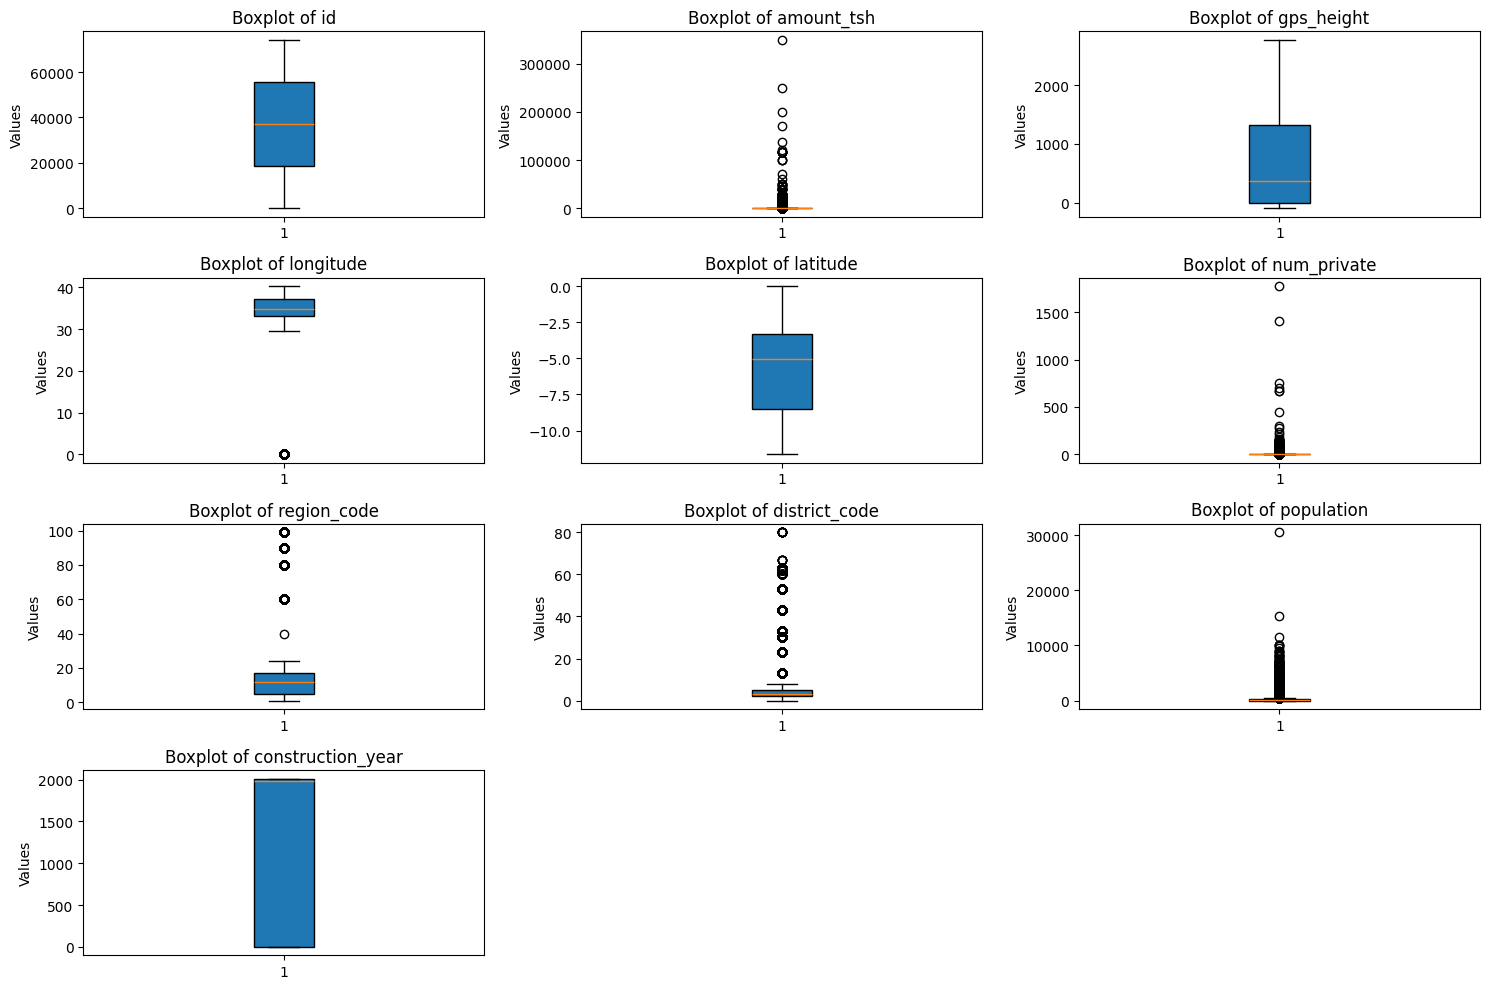

In [14]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols.columns, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')
plt.tight_layout()
plt.show()

 ### `Conclusion`

#### Now we can confirm the skewness conclusion: 
#### a. amount_tsh has extreme outliers so it needs log transformation
#### b. num_private values are almost all zeros with few extreme points
#### c. population needs log tasnformation as well


## 3. Heatmap:

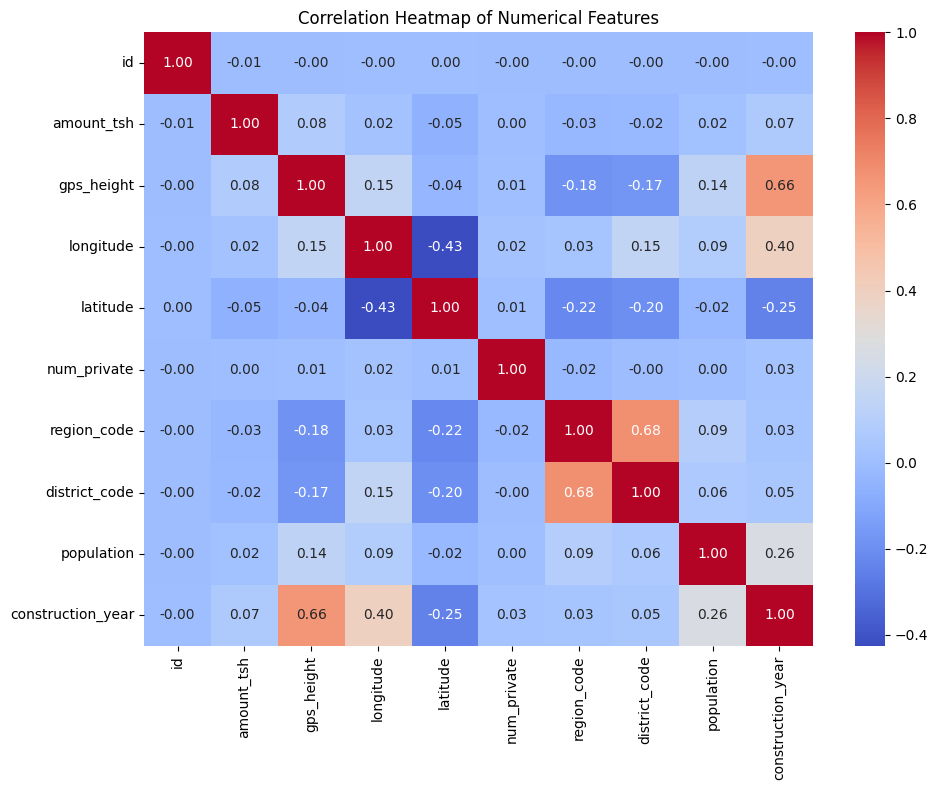

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

 ### `Conclusion`

#### region_code and district_code are highly correlated (0.68) so one may be dropped
#### No feature has a dominant correlation with others
#### num_private has near-zero correlation with everything, so it adds little predictive value (can be removed)

## 4. Boxplots grouped by target 

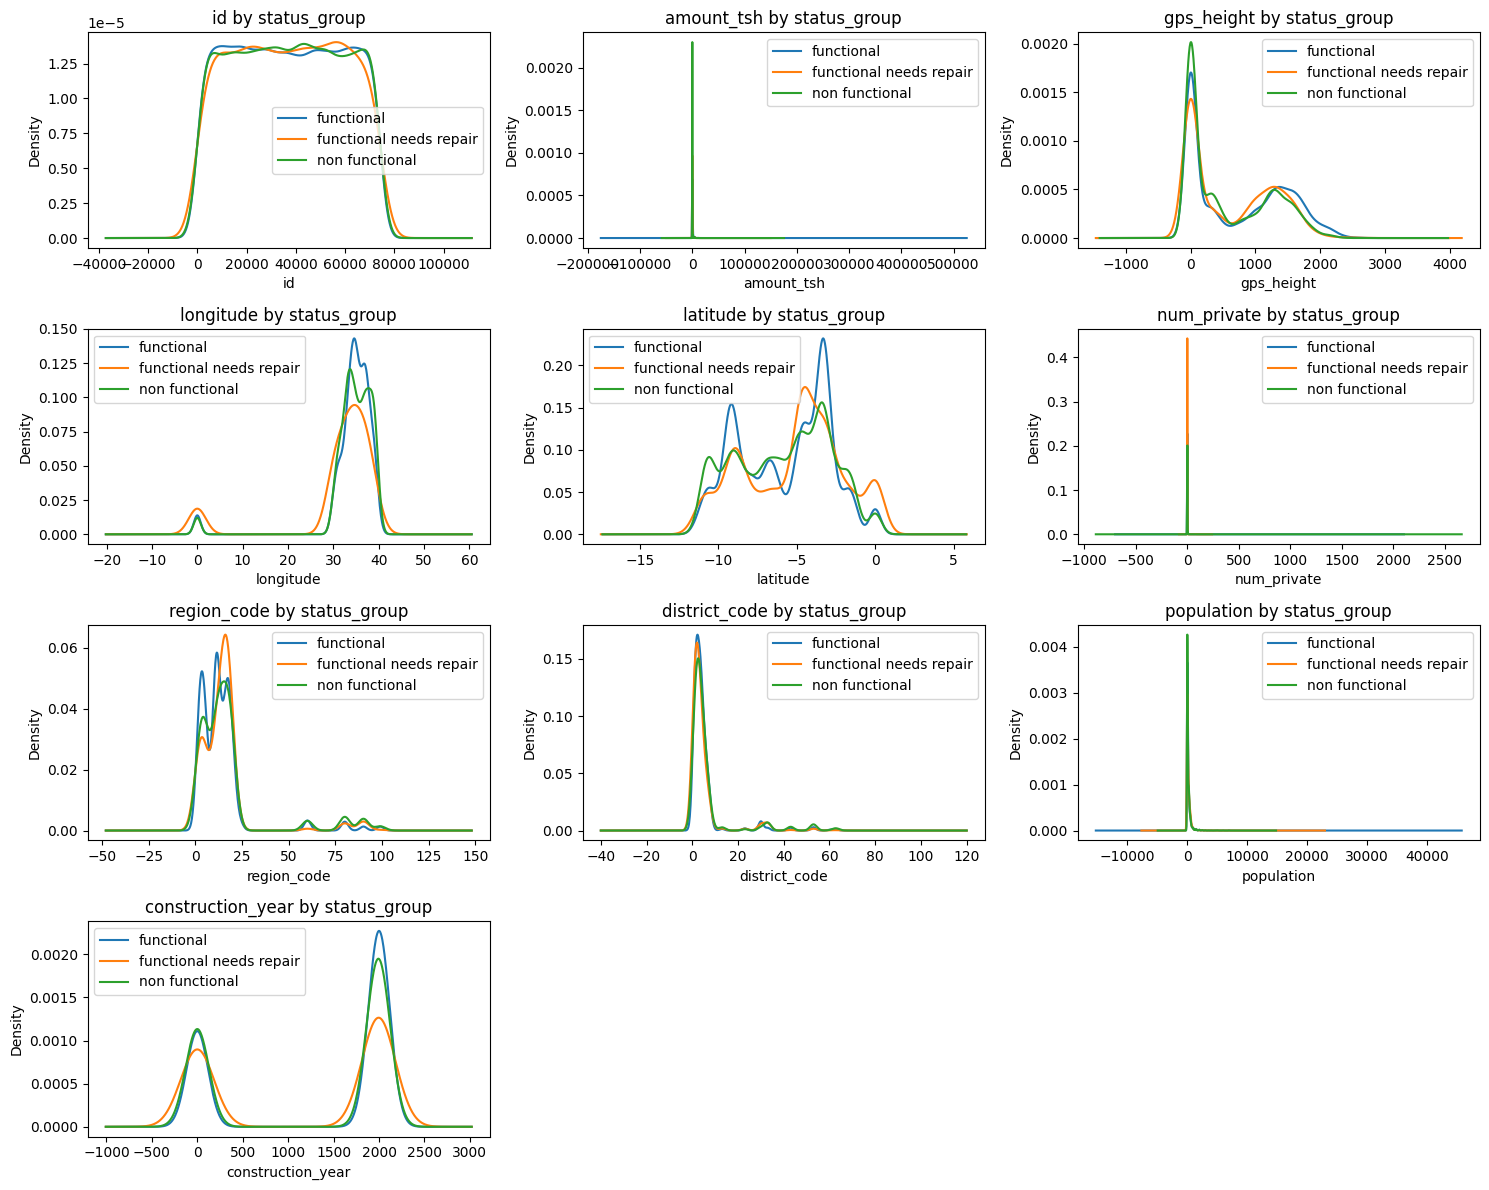

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols.columns):
    df.groupby('status_group')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(f'{col} by status_group')
    axes[i].set_xlabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

 ### `Conclusion`

#### construction_year is the strongest numerical predictor of pump status because the curves are clearly seperated
#### amount_tsh, population appear weak but may show signal after log transformation 
#### id and num_private can be dropped before modeling
#### Geographic features like (latitude, longitude, gps_height) have moderate signal

# EDA for categorical features

## 1. Value counts

In [21]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


date_recorded:
date_recorded
2011-03-15    572
2011-03-17    558
2013-02-03    546
2011-03-14    520
2011-03-16    513
             ... 
2011-09-25      1
2004-04-01      1
2011-09-26      1
2011-09-12      1
2013-12-01      1
Name: count, Length: 356, dtype: int64

funder:
funder
Government Of Tanzania    9084
Danida                    3114
Hesawa                    2202
Rwssp                     1374
World Bank                1349
                          ... 
Cida                         1
Dwe/anglican Church          1
Dina                         1
Brown                        1
Samlo                        1
Name: count, Length: 1896, dtype: int64

installer:
installer
DWE                    17402
Government              1825
RWE                     1206
Commu                   1060
DANIDA                  1050
                       ...  
DWE/Anglican church        1
VIFAI                      1
Dina                       1
brown                      1
SELEPTA                 

/var/folders/bb/h046n8p93s9174l6t457k8gm0000gn/T/ipykernel_24870/2382346048.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


 ### `Conclusion`

#### "recorded_by" has only one unique value so we can drop it as it adds no information
#### quantity/quantity_group, payment/payment_type, water_quality/quality_group, extraction_type_group/class, waterpoint_type_group are duplicate or simplified columns so we should drop one from each pair
#### scheme_name** should be dropped as it has so much unique values and 48.5% missing values

## 2. Bar plots

## we can now select some features or "priorty features" to plot them and not plot everything as it is meaningless

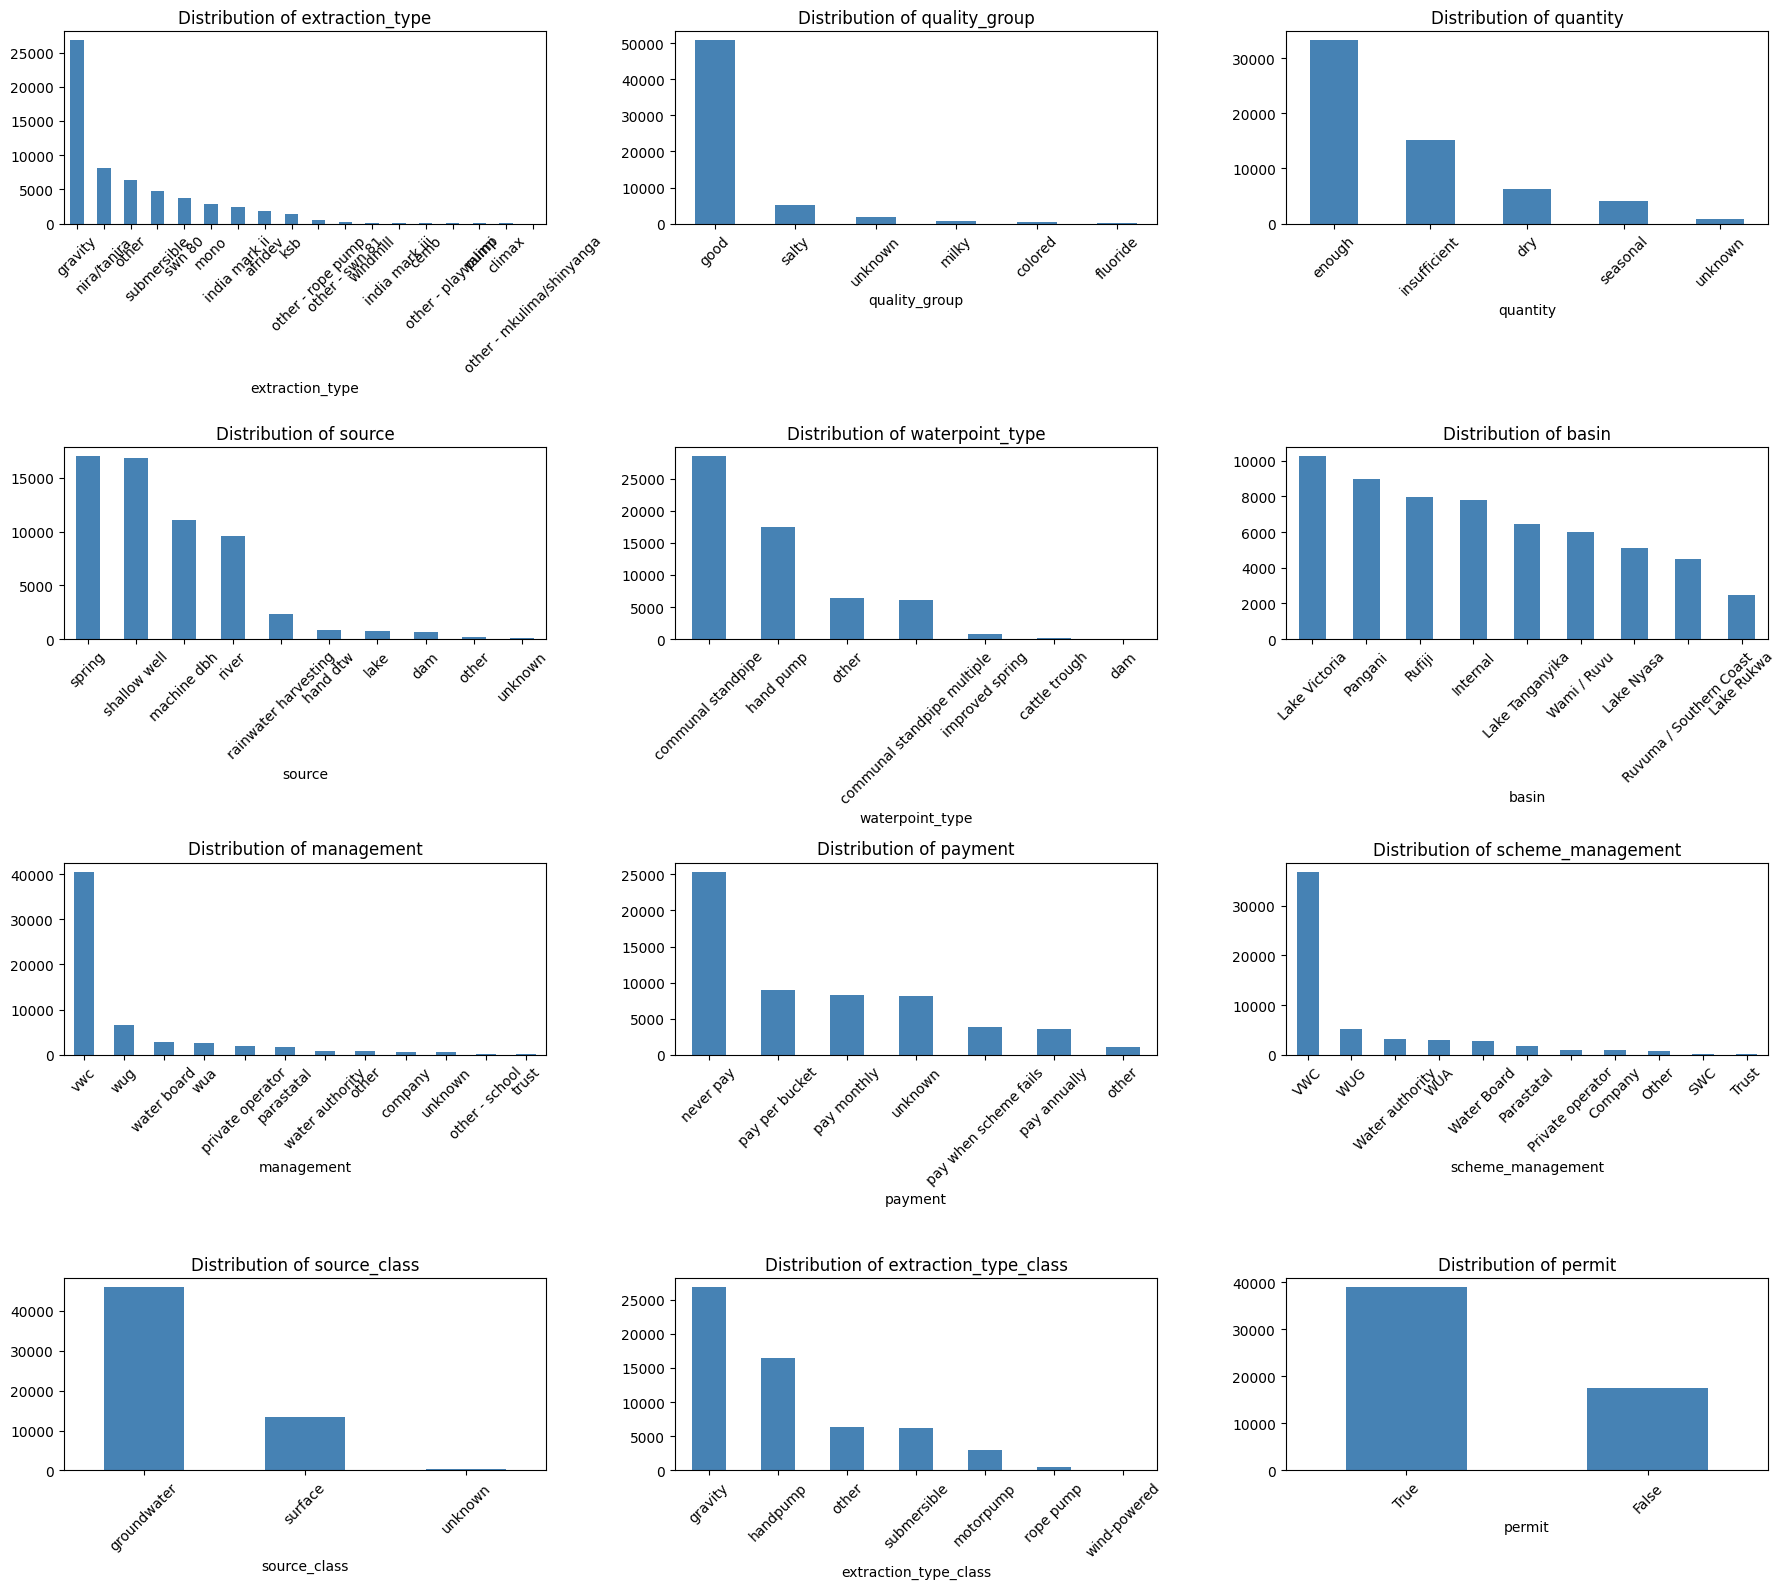

In [22]:
priority_cats = ['extraction_type', 'quality_group', 'quantity', 
                 'source', 'waterpoint_type', 'basin', 
                 'management', 'payment', 'scheme_management',
                 'source_class', 'extraction_type_class', 'permit']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(priority_cats):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

 ### `Conclusion`

#### quality_group and source_class are heavily dominated by one category so they may have low predictive power
#### management and scheme_management are very similar in distribution so we can drop one of them

# 3. Grouped by targed boxplots:

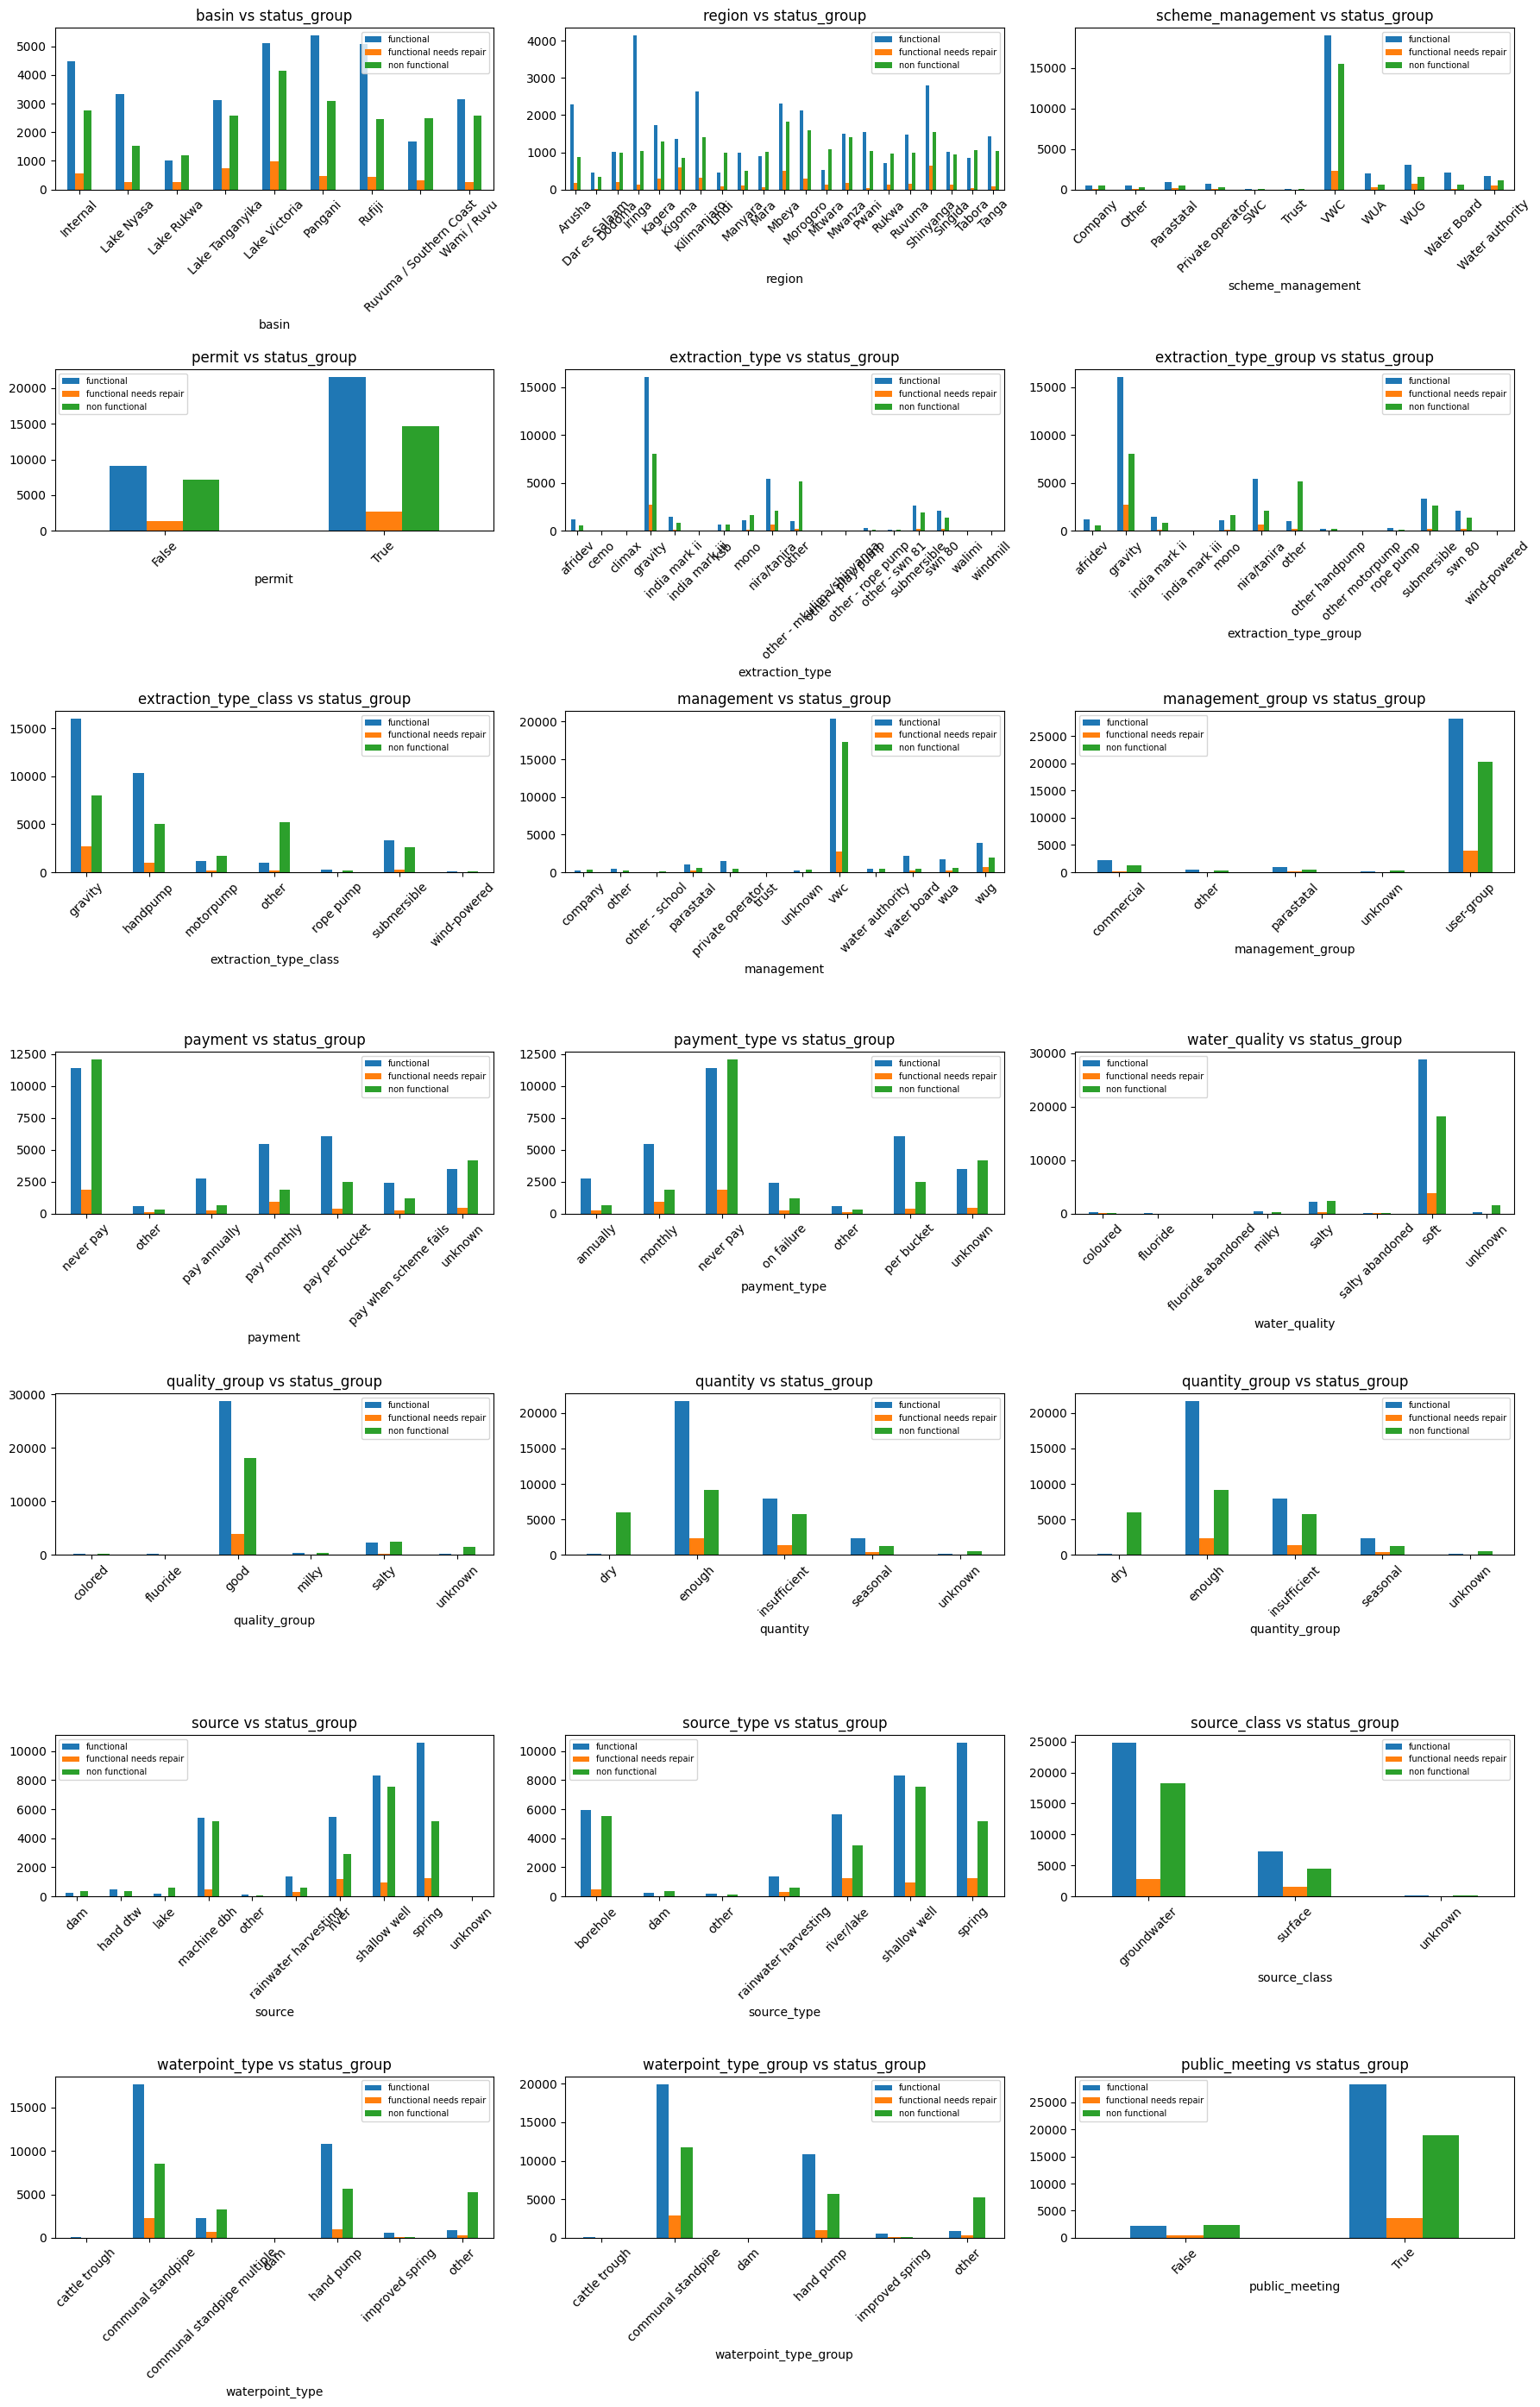

In [24]:
cat_cols = ['basin', 'region', 'scheme_management', 'permit',
            'extraction_type', 'extraction_type_group', 'extraction_type_class',
            'management', 'management_group', 'payment', 'payment_type',
            'water_quality', 'quality_group', 'quantity', 'quantity_group',
            'source', 'source_type', 'source_class', 'waterpoint_type', 
            'waterpoint_type_group', 'public_meeting']

n = len(cat_cols)
rows = (n + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df.groupby([col, 'status_group']).size().unstack().plot(
        kind='bar', ax=axes[i]
    )
    axes[i].set_title(f'{col} vs status_group')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

 ### `Conclusion`

#### quantity, payment, waterpoint_type, source, and extraction_type_class are the strongest predictors of pump status
#### Duplicate columns like (quantity_group, payment_type, waterpoint_type_group, extraction_type_group) show identical patterns  so now we can safely say we should drop them
#### public_meeting adds little value so it can be dropped